# Lift Charts for University Rank Regression
This notebook is all about analyzing how different university features (like number of students or research ranking) relate to the overall ranking of a university. It’s using real data from the [Times World University Rankings](https://www.timeshighereducation.com/world-university-rankings/2022/world-ranking#!/page/0/length/25/sort_by/rank/sort_order/asc/cols/stats) from 2016, which is a famous list of how well universities around the world are ranked. 

The goal is to make lift charts for rank regression problems, these are special plots that help you see how good each feature is at predicting a university’s overall ranking. In other words: which factor seems to matter most for ranking high?

Plot lift charts to compare how well the number of students, student-staff ratio and research ranking predicts the overall ranking of the university. The data has already been converted into rankings for each of these categories. 


Model using research_rank:
  R2: 0.782
  MAE: 20.04
  RMSE: 26.80
  Coefficient: 0.880


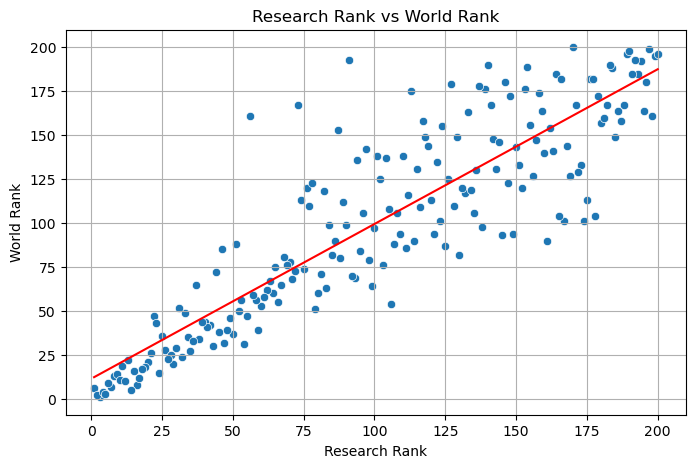


Model using student_staff_ratio_rank:
  R2: 0.044
  MAE: 48.75
  RMSE: 56.16
  Coefficient: -0.208


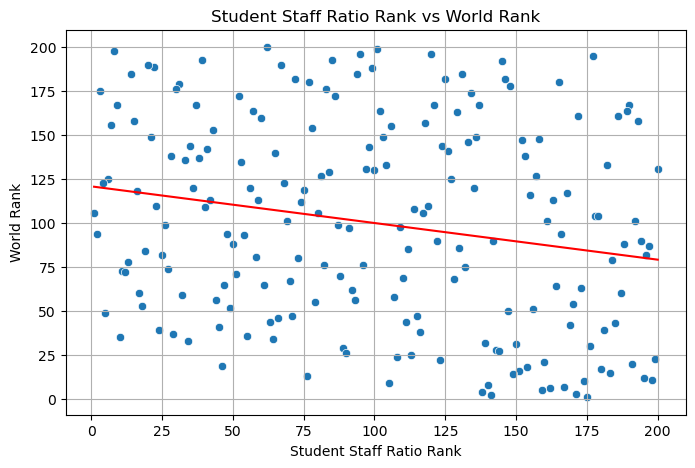


Model using num_students_rank:
  R2: 0.000
  MAE: 49.61
  RMSE: 57.43
  Coefficient: -0.008


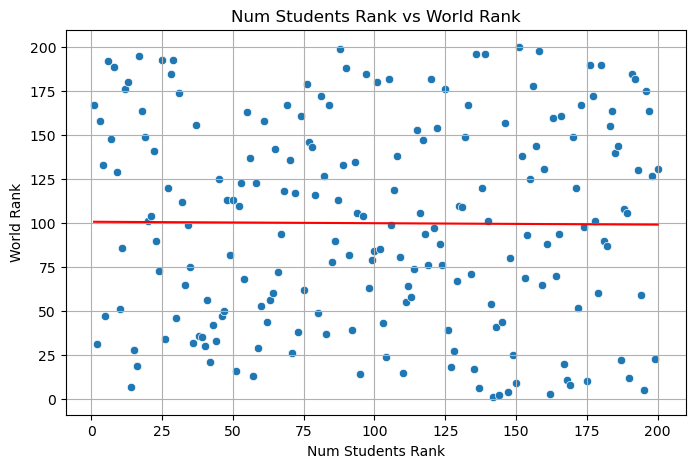


Combined Model:
  R2: 0.809
  MAE: 18.74
  RMSE: 25.07
  Coefficients: {'research_rank': 0.8726085332598157, 'student_staff_ratio_rank': -0.15849499080127027, 'num_students_rank': -0.03541230362865673}


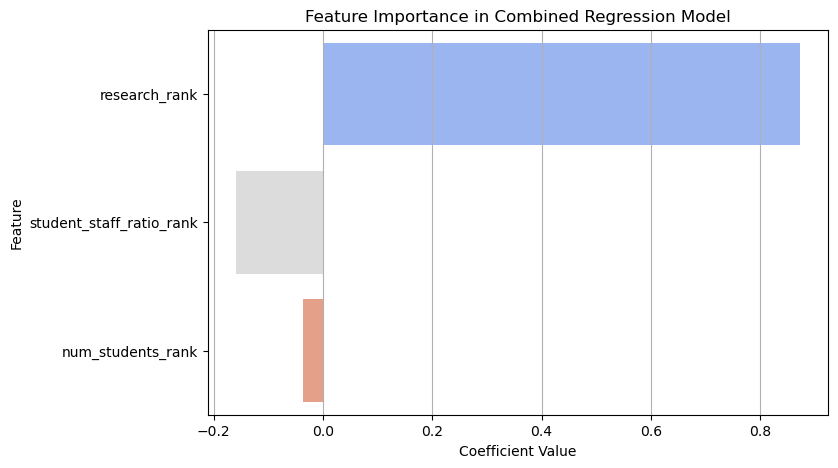

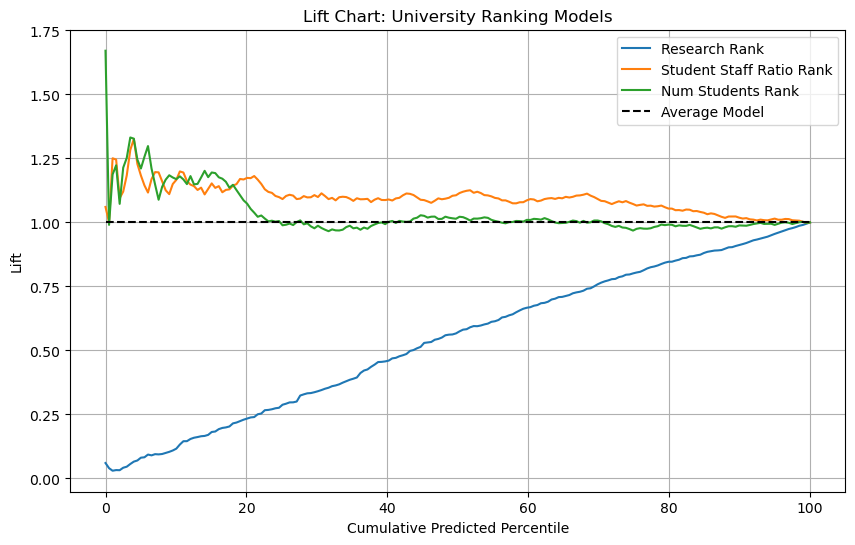

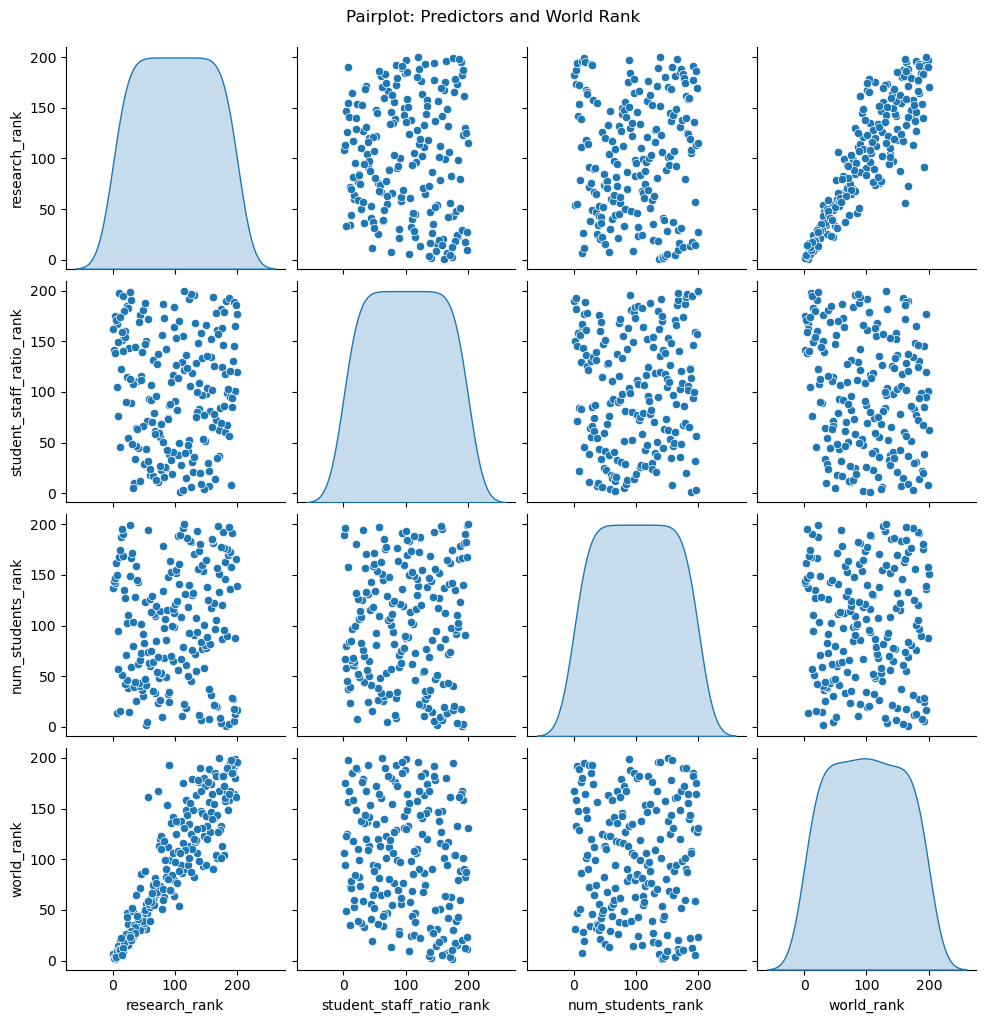

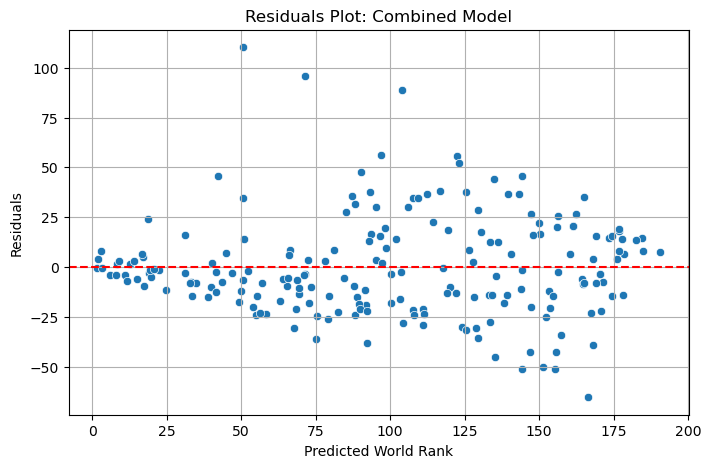

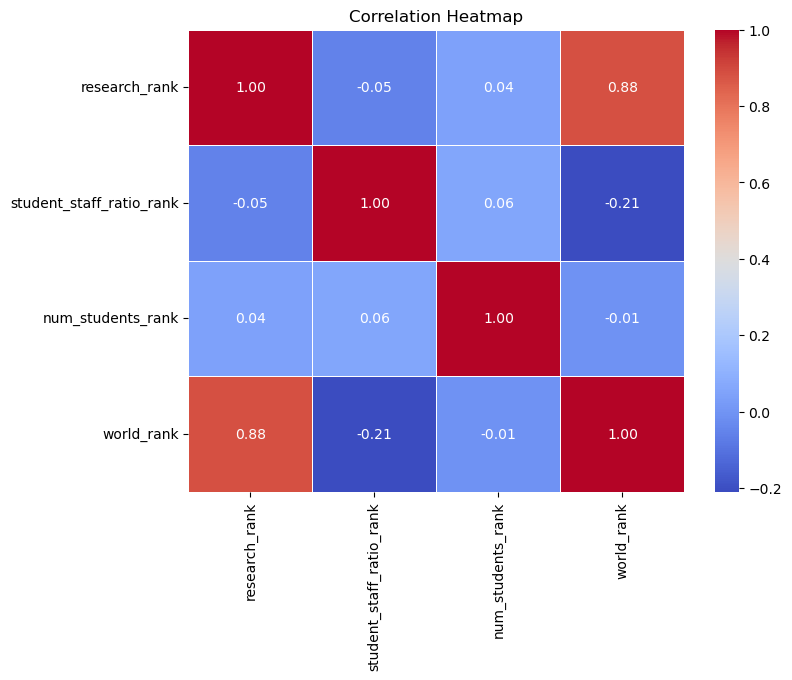

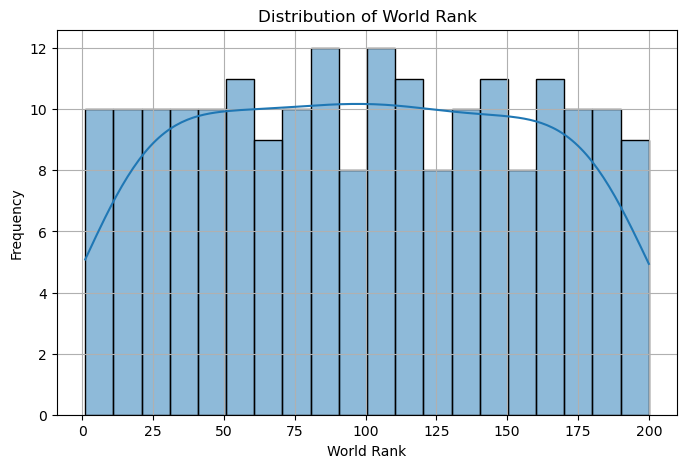

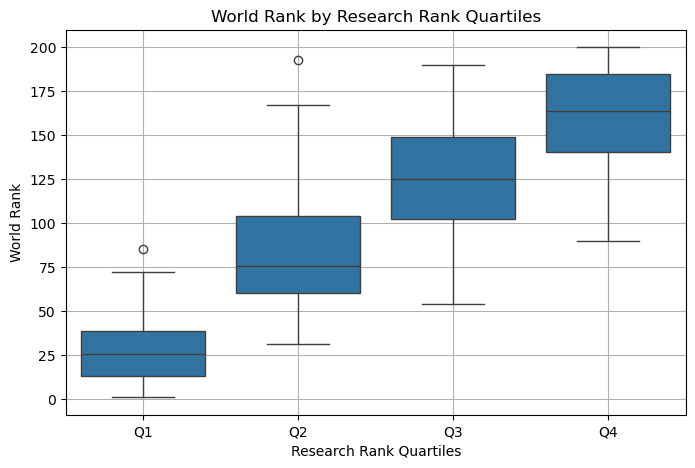

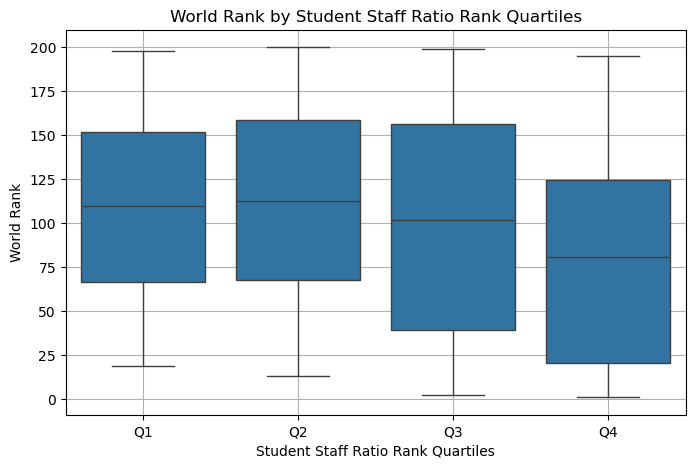

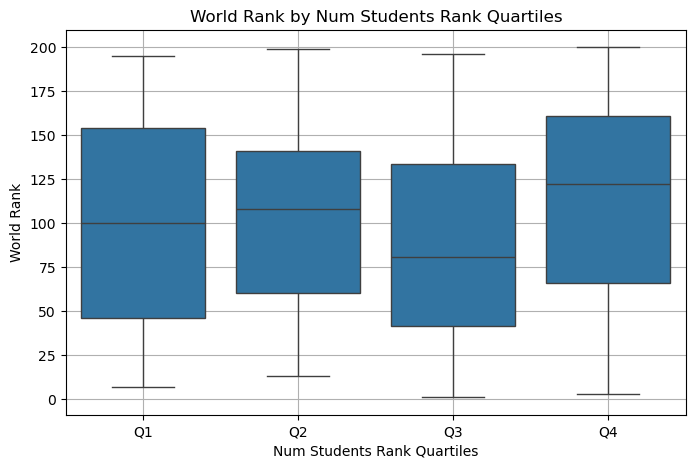

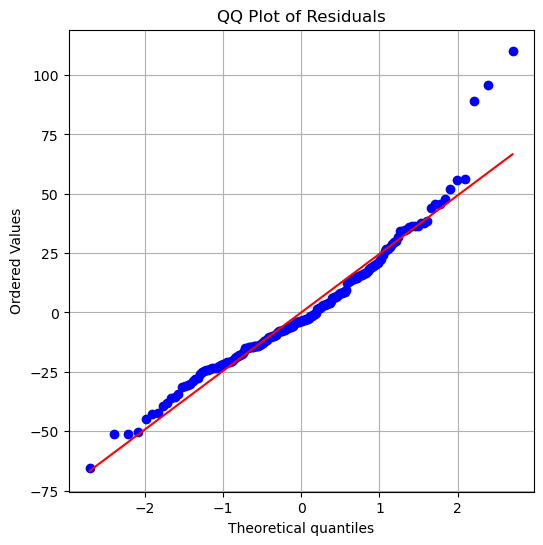

In [99]:
# --- Step 1: Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

# --- Step 2: Load the dataset ---
df = pd.read_csv('C6-Uni_Ranking.csv')

df = df.dropna()

# --- Step 3: Set up predictors and target ---
predictors = ['research_rank', 'student_staff_ratio_rank', 'num_students_rank']
target = 'world_rank'

results = {}

# --- Step 4: Fit regression models ---
for predictor in predictors:
    X = df[[predictor]]
    y = df[target]
    model = LinearRegression()
    model.fit(X, y)
    preds = model.predict(X)
    
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    
    results[predictor] = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'Coefficient': model.coef_[0]
    }
    
    print(f"\nModel using {predictor}:")
    print(f"  R2: {r2:.3f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  Coefficient: {model.coef_[0]:.3f}")

    # Scatter plot with regression line
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=predictor, y=target, data=df)
    sns.lineplot(x=df[predictor], y=preds, color='red')
    plt.title(f'{predictor.replace("_", " ").title()} vs World Rank')
    plt.xlabel(predictor.replace("_", " ").title())
    plt.ylabel('World Rank')
    plt.grid(True)
    plt.show()

# --- Step 5: Fit combined model ---
X_combined = df[predictors]
y = df[target]

combined_model = LinearRegression()
combined_model.fit(X_combined, y)
preds_combined = combined_model.predict(X_combined)

r2_comb = r2_score(y, preds_combined)
mae_comb = mean_absolute_error(y, preds_combined)
rmse_comb = np.sqrt(mean_squared_error(y, preds_combined))

results['Combined'] = {
    'R2': r2_comb,
    'MAE': mae_comb,
    'RMSE': rmse_comb,
    'Coefficients': combined_model.coef_
}

print("\nCombined Model:")
print(f"  R2: {r2_comb:.3f}")
print(f"  MAE: {mae_comb:.2f}")
print(f"  RMSE: {rmse_comb:.2f}")
print(f"  Coefficients: {dict(zip(predictors, combined_model.coef_))}")

# --- Step 6: Feature importance bar plot ---
coef_df = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': combined_model.coef_
})

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance in Combined Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.show()

# --- Step 7: Lift Chart ---
plt.figure(figsize=(10, 6))

for predictor in predictors:
    sorted_df = df.sort_values(by=predictor)
    cumulative_mean = np.cumsum(sorted_df[target]) / np.arange(1, len(sorted_df)+1)
    lift = cumulative_mean / df[target].mean()
    plt.plot(np.linspace(0, 100, len(lift)), lift, label=f'{predictor.replace("_", " ").title()}')

plt.plot([0, 100], [1, 1], 'k--', label='Average Model')
plt.xlabel('Cumulative Predicted Percentile')
plt.ylabel('Lift')
plt.title('Lift Chart: University Ranking Models')
plt.legend()
plt.grid(True)
plt.show()

# --- Step 8: Pairplot of Predictors vs World Rank ---
sns.pairplot(df, vars=predictors + [target], diag_kind='kde')
plt.suptitle('Pairplot: Predictors and World Rank', y=1.02)
plt.show()

# --- Step 9: Residuals Plot ---
residuals = y - preds_combined

plt.figure(figsize=(8, 5))
sns.scatterplot(x=preds_combined, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Plot: Combined Model')
plt.xlabel('Predicted World Rank')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# --- Additional Plot 1: Correlation Heatmap ---
corr_matrix = df[predictors + [target]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# --- Additional Plot 2: Distribution of World Rank ---
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=20, kde=True)
plt.title('Distribution of World Rank')
plt.xlabel('World Rank')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# --- Additional Plot 3: Boxplots of World Rank by Quartiles of Each Predictor ---
for predictor in predictors:
    df['quartile'] = pd.qcut(df[predictor], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='quartile', y=target, data=df)
    plt.title(f'World Rank by {predictor.replace("_", " ").title()} Quartiles')
    plt.xlabel(f'{predictor.replace("_", " ").title()} Quartiles')
    plt.ylabel('World Rank')
    plt.grid(True)
    plt.show()
    df.drop(columns=['quartile'], inplace=True)

# --- Additional Plot 4: QQ Plot of Residuals ---
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals')
plt.grid(True)
plt.show()

# Understanding the Visuals 
## 1. Feature Importance Plot:
This shows how much each factor (like research rank, student-staff ratio rank, and number of students rank) contributes to predicting the university’s world rank.
We see that research rank has by far the strongest effect, meaning that a university’s research performance is the best single predictor of its world ranking. The other two features (student-staff ratio and number of students) have much smaller influences.
## 2. Lift Chart:
This plot compares how well each model (based on each factor) improves prediction over just using the average.
The research rank line climbs steeply, showing it gives the best “lift” (improvement) when identifying top-ranked universities. The other lines are flatter, meaning they don’t add much predictive power.
## 3. Pairplot:
This grid of scatterplots shows the relationships between all the factors and the world rank.
You can see that research rank has a clearer upward trend with world rank (meaning higher research rank → better world rank), while the other features look more scattered, showing weaker connections.
## 4. Correlation Heatmap:
This is like a temperature map of how strongly things are related (from -1 to +1).
The deep color between research rank and world rank (about 0.88) means they are highly correlated. Other relationships are weak or even close to zero, confirming that research strength is key.
## 5. Residuals Plot:
This shows the difference between the predicted and actual world rank. Ideally, the points should scatter randomly around zero, which means the model is fair.
We see some spread, but no huge pattern, which tells us the model is reasonably balanced but might miss some complexities.
## 6. Distribution of World Rank:
This shows how world ranks are spread out across universities. The ranks are pretty evenly spread, meaning we have a good mix of top, middle, and lower-ranked schools in the data.
## 7. Boxplots (Quartiles):
These break each factor into four groups (quartiles) and show how world rank changes in each.
	• For research rank, the better the research rank (Q1), the better the world rank, and the pattern is clear.
	• For number of students, the pattern is less obvious, suggesting that having more students doesn’t clearly relate to world ranking.
## 8. QQ Plot:
This tests if the prediction errors (residuals) are normally distributed, which is a basic check in regression. The points mostly follow the straight line, but some points at the top curve away, which hints at a few outliers or bigger errors.

## Objective:
We analyzed the impact of research rank, student-staff ratio rank, and number of students rank on predicting university world rankings using linear regression.

## Key Findings:
	• Research rank is the strongest predictor. It shows a clear, strong correlation with world rank and dominates both in coefficient size and in model performance.
	• Student-staff ratio and number of students have weaker effects. Their influence on world ranking is minimal and adds little improvement when combined with research rank.
	• Model diagnostics:
    	• The residuals plot suggests no major bias, though a few outliers exist.
    	• The QQ plot shows that residuals are generally well-behaved but slightly deviate at the extremes.
	• Lift analysis confirms that research rank provides the most predictive lift, especially for top-performing universities.

## Conclusions:
The study confirms that research strength is the single most important driver of a university’s world ranking in this dataset. Other factors like student-staff ratio and student size add little explanatory power. For future improvements, we might explore adding other features (like international outlook, teaching reputation, or funding) or testing non-linear models to capture deeper patterns.